[Link](https://www.kaggle.com/datasets/fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid?resource=download)

# About Data

According to the provided information, the medical dataset classifies either heart attack or none. The gender column in the data is normalized: the male is set to 1 and the female to 0. The glucose column is set to 1 if it is > 120; otherwise, 0. As for the output, positive is set to 1 and negative to 0.

The dataset has 9 column:

- Age: The patient's age
- Gender: Biological sex of the patient (The male is set to 1 and the female to 0)
- Heart Rate: The number of heartbeats per minute
- Systolic Blood Pressure: The pressure in arteries when the heart contracts
- Diastolic Blood Pressure: The pressure in arteries between heartbeats
- Blood Sugar: The patient's blood glucose level
- Ck-mb: A cardiac enzyme released during heart muscle damage
     - 심장 근육에 존재하는 효소로, 심장 근육이 손상되면 방출된다.
- Troponin:A highly specific protein biomarker for heart muscle injury
    - 심장 근육 수축에 관여하는 단백질
- Result: The outcome label indicating whether or not the patient experienced a heart attack

# Import

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

# Data

In [5]:
df = pd.read_csv("../../../../delete/Medicaldataset.csv")
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [8]:
df['Result'] = df['Result'].map({'negative': 0, 'positive': 1})

In [9]:
df['Result'].value_counts()

1    810
0    509
Name: Result, dtype: int64

# EMA

- Age

Text(0, 0.5, 'Count')

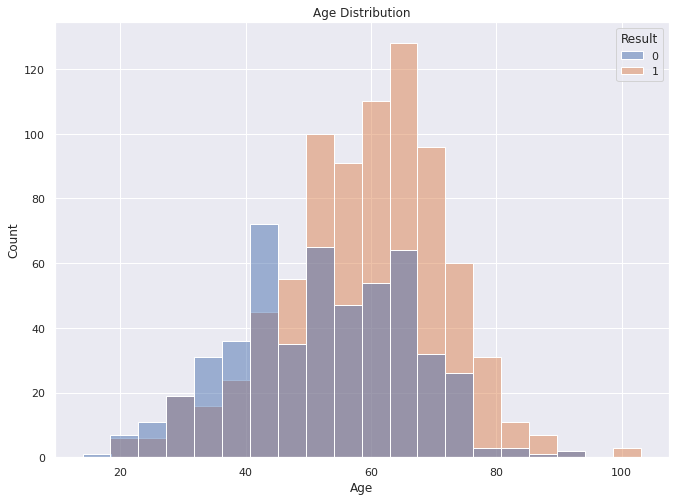

In [22]:
sns.histplot(data=df, x='Age', hue='Result', bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

- Gender

Text(0.5, 1.0, 'Gender Distribution')

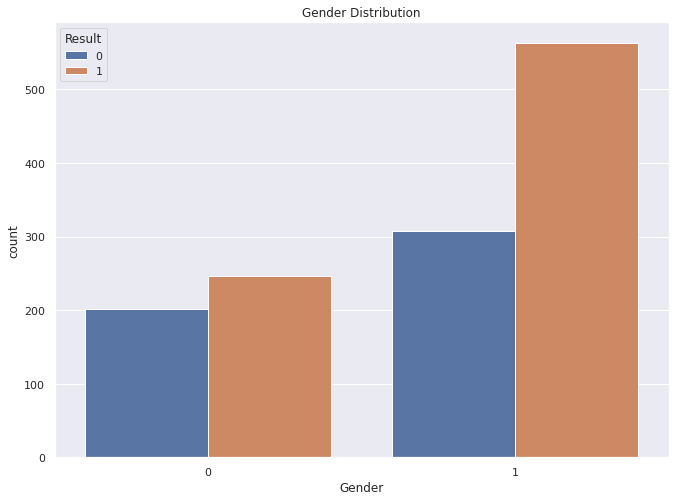

In [28]:
sns.countplot(x='Gender', hue='Result', data=df)
plt.title("Gender Distribution")

- Data distribution check

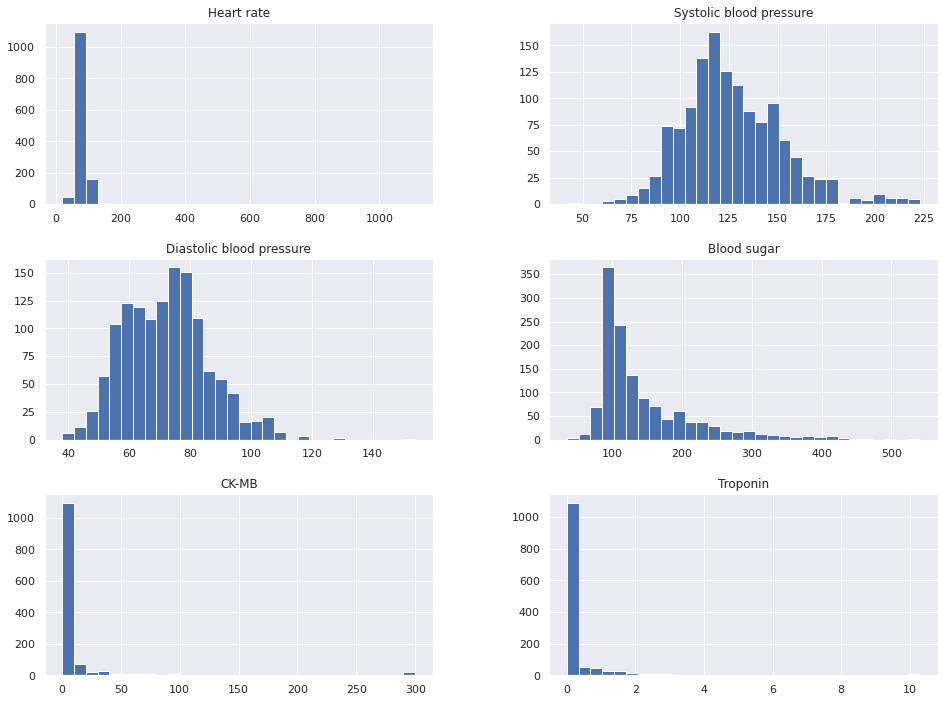

In [45]:
cols = ['Heart rate','Systolic blood pressure','Diastolic blood pressure','Blood sugar','CK-MB','Troponin']
df[cols].hist(figsize=(16,12),bins=30);

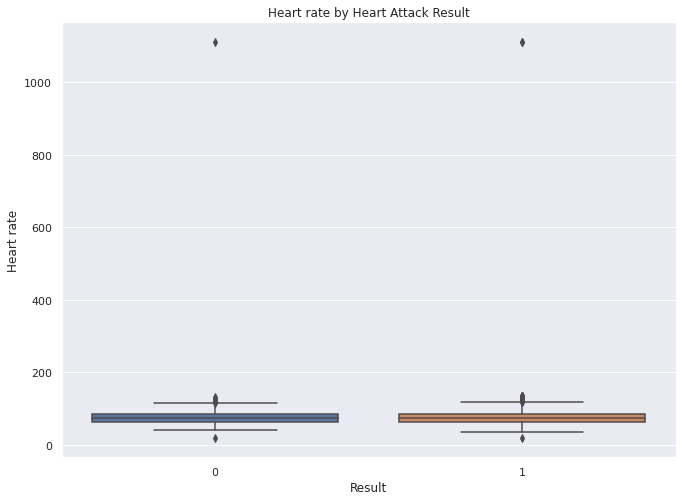

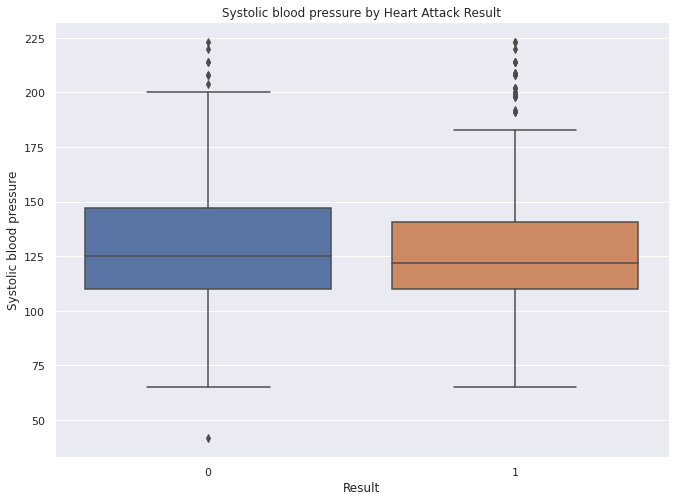

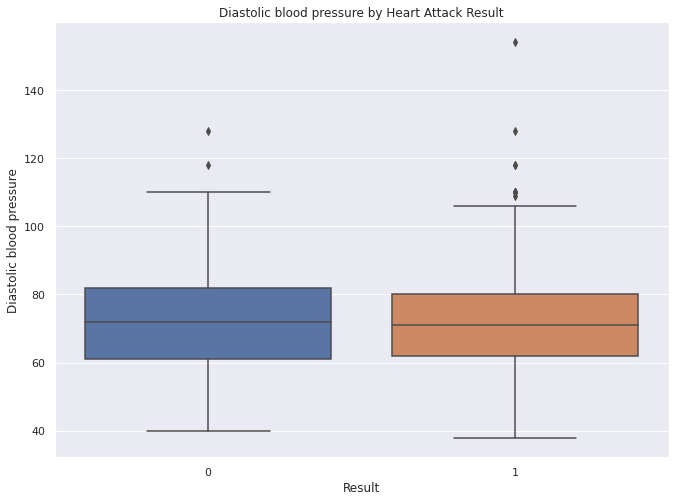

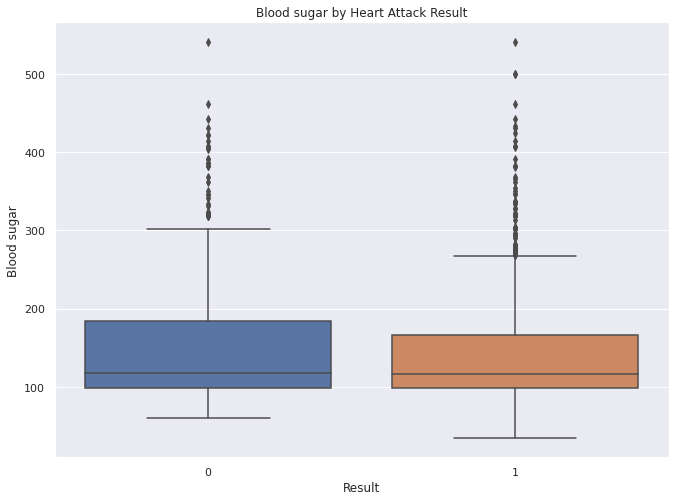

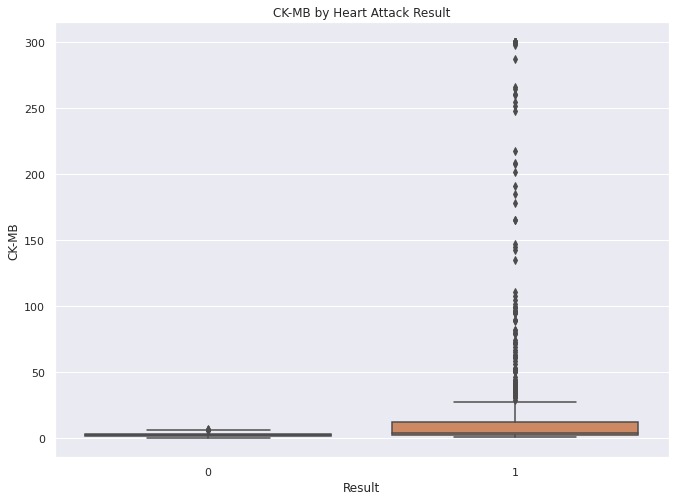

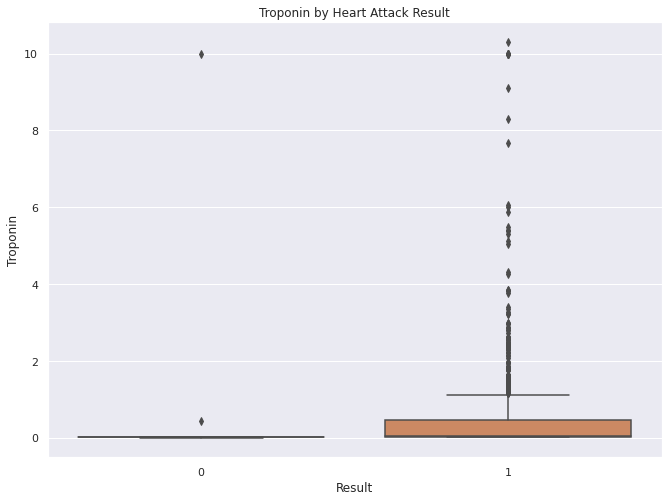

In [33]:
for col in cols:
    sns.boxplot(x='Result', y=col, data=df)
    plt.title(col + " by Heart Attack Result")
    plt.show()

- ttest

In [54]:
for col in cols:
    g0 = df[df['Result']==0][col]
    g1 = df[df['Result']==1][col]

    t,p = ttest_ind(g0,g1)
    print(col, "p-value:", round(p,2))

Heart rate p-value: 0.8
Systolic blood pressure p-value: 0.45
Diastolic blood pressure p-value: 0.73
Blood sugar p-value: 0.23
CK-MB p-value: 0.0
Troponin p-value: 0.0


- data outliers

Values outside physiologically plausible ranges (e.g., heart rate > 250 bpm) were treated as data entry errors and set to missing.

In [60]:
df['Heart rate'].describe()

count    1319.000000
mean       78.336619
std        51.630270
min        20.000000
25%        64.000000
50%        74.000000
75%        85.000000
max      1111.000000
Name: Heart rate, dtype: float64

In [61]:
df.sort_values('Heart rate', ascending=False).head(5)

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
1069,32,0,1111,141,95,82.0,2.66,0.008,0
717,70,0,1111,141,95,138.0,3.87,0.028,1
63,45,1,1111,141,95,109.0,1.33,1.010,1
682,68,1,135,98,60,96.0,254.40,0.025,1
1012,65,1,135,98,60,162.0,7.67,0.025,1


In [62]:
df = df[df['Heart rate'] < 250]

In [68]:
df.sort_values('CK-MB', ascending=False).head(20)

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
1209,59,1,87,148,89,431.0,300.0,1.230,1
82,50,1,93,119,63,174.0,300.0,0.888,1
28,47,0,66,134,57,279.0,300.0,0.007,1
997,86,1,60,154,81,112.0,300.0,1.790,1
651,70,1,100,169,91,303.0,300.0,0.015,1
472,31,1,61,102,64,104.0,300.0,0.003,1
1259,68,0,59,107,64,225.0,300.0,0.016,1
1215,63,1,101,102,63,166.0,300.0,0.022,1
451,63,1,60,117,68,226.0,300.0,0.025,1
1047,55,0,96,105,70,66.0,300.0,0.003,1
